In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import os

from utils.visualization import BLUE, GREEN, standard_setup
standard_setup()

## Functies

In [3]:
def generate_linreg(slope, intercept, noise_std, num_samples=100, x_bounds = [0, 10]):
    """
    Generate linear regression data with noise.
    
    Parameters:
    - slope: Slope of the line.
    - intercept: Intercept of the line.
    - noise_std: Standard deviation of the noise.
    - num_samples: Number of samples to generate.
    
    Returns:
    - x: Array of x-values.
    - y: Array of corresponding y-values.
    """
    # Generate x values
    x = np.random.uniform(x_bounds[0], x_bounds[1], num_samples)
    
    # Generate noise
    noise = np.random.normal(0, noise_std, num_samples)
    
    # Generate y values
    y = slope * x + intercept + noise
    
    return x, y

def plot_linreg(slope, 
                    intercept, 
                    noise_std, 
                    num_samples, 
                    ax, 
                    x_bounds = [0, 10], 
                    add_vlines = False, 
                    include_cov = True, 
                    include_loss = False):
    """
    Generate linear regression data with noise and plot the points along with the linear regression line.
    
    Parameters:
    - x_all: Array of x-values.
    - y_all: Array of corresponding y-values.
    - slope: Slope of the line.
    - intercept: Intercept of the line.
    - noise_std: Standard deviation of the noise.
    - num_samples: Number of samples to take from x, y. Is capped at len(x_all)
    """

    y_bounds = [intercept + slope * x_bounds[0], intercept + slope * x_bounds[1]]
    x, y = generate_linreg(slope, intercept, noise_std, num_samples, x_bounds=x_bounds)

    # Compute optimal linear regression line
    model = LinearRegression()
    model.fit(x.reshape(-1, 1), y)
    x_range = np.linspace(x_bounds[0], x_bounds[1], 100)
    y_predicted = model.predict(x_range.reshape(-1, 1))
    
    # Plot linear regression line
    y_exact = slope * np.array(x_range) + intercept

    ax.scatter(x, y, label='Datapunten', color = BLUE, alpha = 0.8)
    ax.plot(x_range, y_predicted, lw = 2, label='Lineaire Regressie Line', color = GREEN)
    
    #ax.set_xlim(x_bounds)
    #ax.set_ylim(y_bounds)
    ax.spines[['top', 'right']].set_visible(False)

    # Add labels and legend
    ax.set_xlabel('Label')
    ax.set_ylabel('Feature')
    ax.set_title('Lineaire regressie met ruis')
    legend = ax.legend(bbox_to_anchor = (-0.2, 1),
                        frameon = False)
    
    # Add information to plot
    if include_cov:
        cov_text = "$S_{xy} = $" + f"${np.cov(x, y)[0][1]:.2f}$"
        cor_text = "$R_{xy} = $" + f"${np.corrcoef(x, y)[0][1]:.2f}$"
        r_squared_text = "$R_{xy}^2 = R_x^2 = $" + f"${np.corrcoef(x, y)[0][1] ** 2:.2f}$"
        ax.text(-0.5, 0.5, cov_text, horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, fontsize=20)
        ax.text(-0.5, 0.4, cor_text, horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, fontsize=20)
        ax.text(-0.5, 0.3, r_squared_text, horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, fontsize=20)

    if include_loss:
        residuals = list()
        for x_val, y_val in zip(x, y):
            y_pred =  model.predict(np.array([x_val]).reshape(-1, 1))[0]
            residuals.append(str(np.round(np.abs(y_val - y_pred), 1)))
        rmse = np.sqrt(np.mean([float(res) ** 2 for res in residuals]))
        residuals_text = f"Residuen:\n{'; '.join(residuals)}"
        ax.text(-0.8, 0.5, residuals_text, horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, fontsize=20)
        ax.text(-0.8, 0.3, f"Gemiddelde loss: {rmse:2f}", horizontalalignment = 'left', verticalalignment = 'center', transform=ax.transAxes, fontsize=20)


    if add_vlines:
        for x_val, y_val in zip(x, y):
            y_pred =  model.predict(np.array([x_val]).reshape(-1, 1))[0]
            ax.plot([x_val, x_val], [y_val, y_pred], color='k', linestyle='--', alpha=0.5)
    return

## Locaties

In [4]:
locs = {'Covariance' : 'figures/covariantie',
            'loss_functon' : 'figures/loss_functies',
            'bloeddruk' : '../../../DATA/bloeddruk.csv',
            'bloeddruk_figs' : 'figures/bloeddruk'}

## Covariantie, correlatie & R-squared

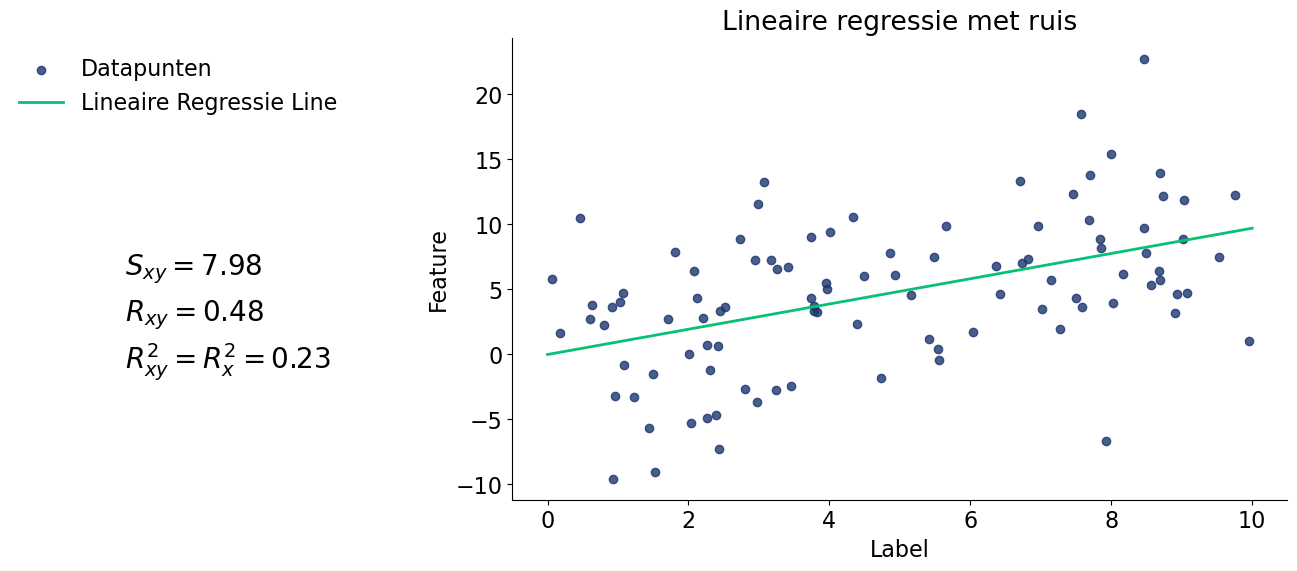

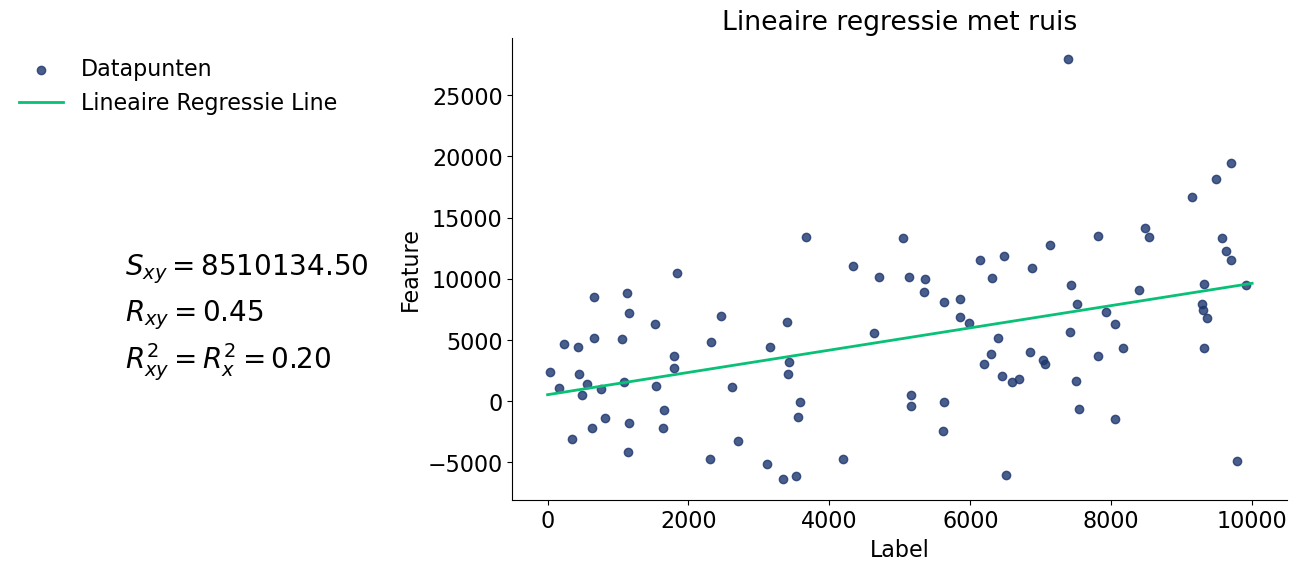

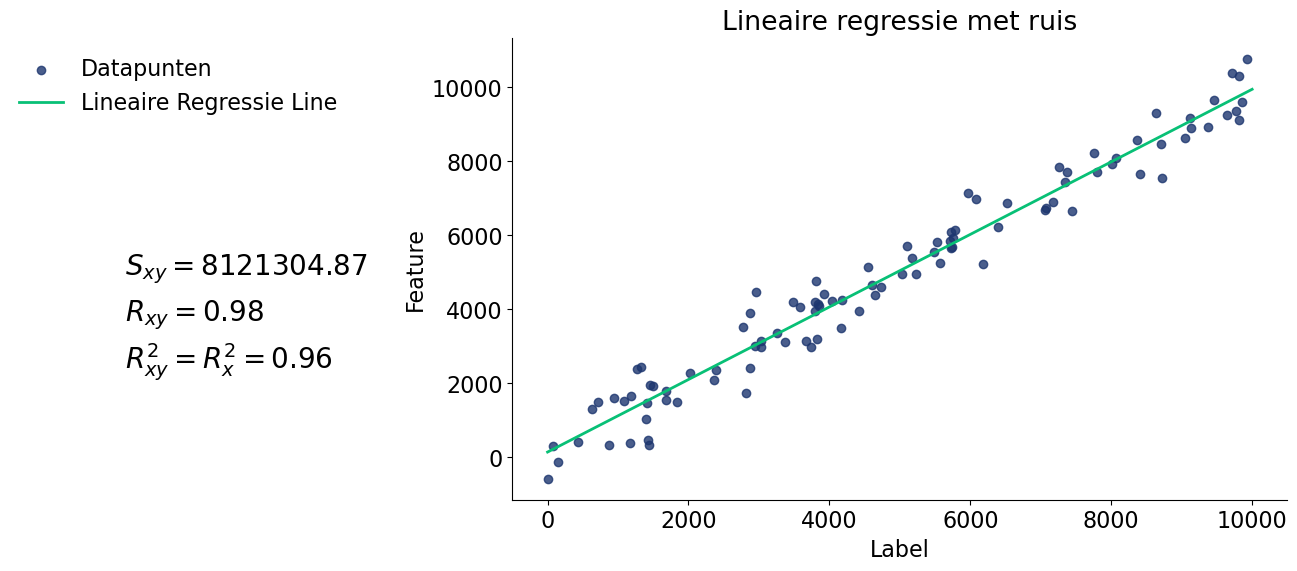

In [5]:
slope = 1
intercept = 0
num_samples = 100

x_bounds = [0, 10]
noise_std = 5

fig, ax = plt.subplots()
plot_linreg(slope, intercept, noise_std, num_samples, ax, x_bounds = x_bounds)
# fig.savefig(os.path.join(locs['Covariance'], 'linreg_plot1.png'), transparent=True, bbox_inches='tight')

x_bounds = [0, 10**4]
noise_std = 5 * 10 ** 3
fig, ax = plt.subplots()
plot_linreg(slope, intercept, noise_std, num_samples, ax, x_bounds = x_bounds)
# fig.savefig(os.path.join(locs['Covariance'], 'linreg_plot2.png'), transparent=True, bbox_inches='tight')

x_bounds = [0, 10**4]
noise_std = 5 * 10 ** 2
fig, ax = plt.subplots()
plot_linreg(slope, intercept, noise_std, num_samples, ax, x_bounds = x_bounds)
# fig.savefig(os.path.join(locs['Covariance'], 'linreg_plot3.png'), transparent=True, bbox_inches='tight')

## Lineaire regressie op bivariate gegevens

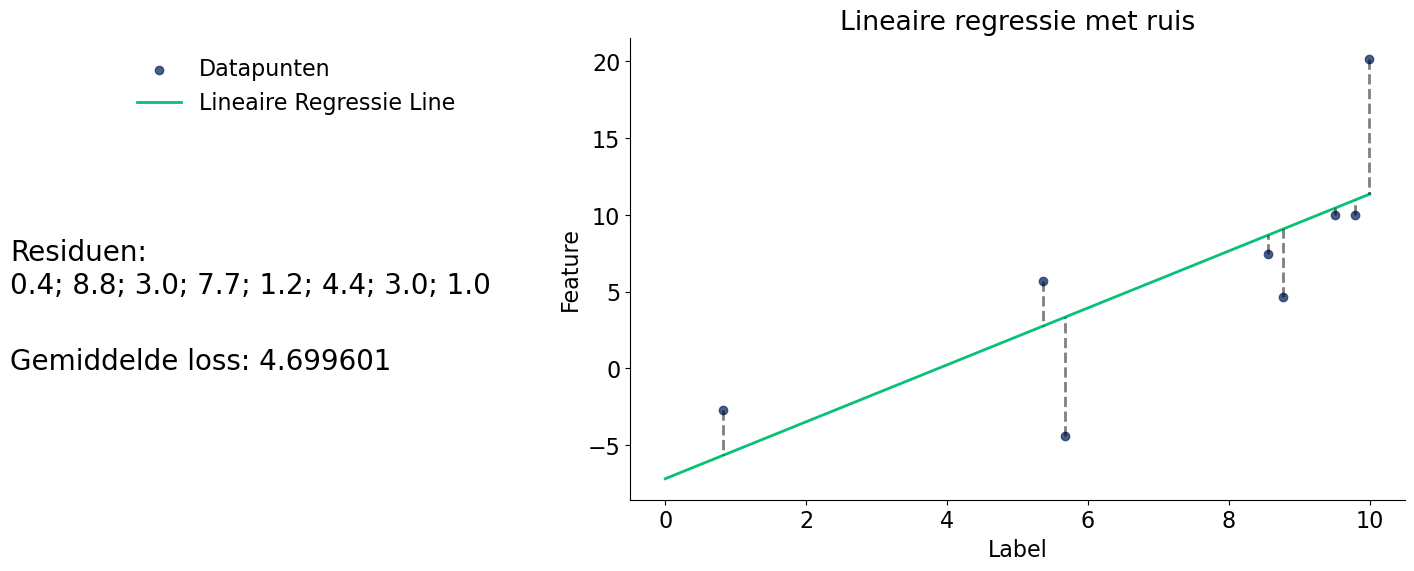

In [6]:
slope = 1
intercept = 0
num_samples = 8

x_bounds = [0, 10]
noise_std = 5

fig, ax = plt.subplots()
plot_linreg(slope, intercept, noise_std, num_samples, ax, x_bounds = x_bounds, add_vlines=True, include_cov=False, include_loss=True)
# fig.savefig(os.path.join(locs['loss_functon'], 'loss_vbd1.png'), transparent=True, bbox_inches='tight')

## Voorbeeld: bloeddruk

In [7]:
df = pd.read_csv(locs['bloeddruk'])

### Stap 1: Verkennend

R_xy = 0.96
R_xy ** 2 = 0.91


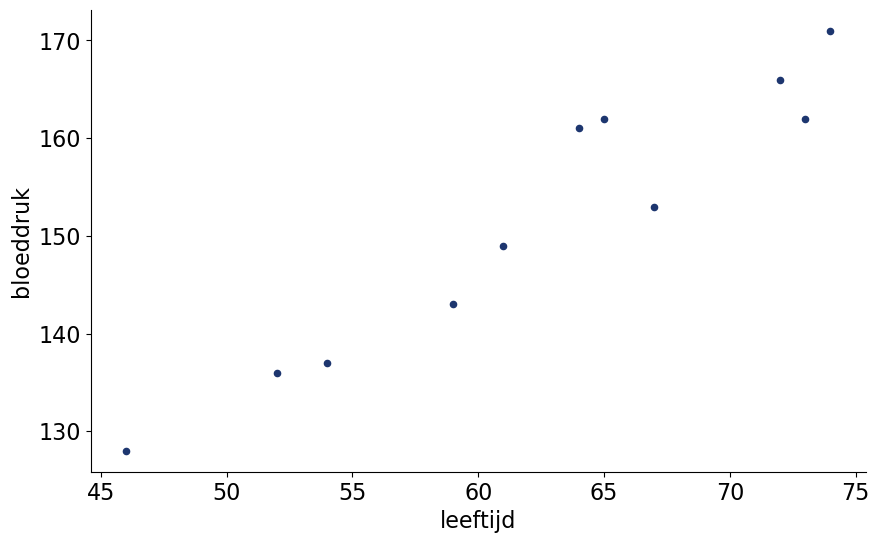

In [8]:
fig, ax = plt.subplots()
df.plot.scatter(x = 'leeftijd', y = 'bloeddruk', color = BLUE, ax = ax)
ax.spines[['top', 'right']].set_visible(False)
# fig.savefig(os.path.join(locs['bloeddruk_figs'], 'scatter_1d.png'))

print(f"R_xy = {df.corr().loc['leeftijd', 'bloeddruk']:.2f}")
print(f"R_xy ** 2 = {df.corr().loc['leeftijd', 'bloeddruk'] ** 2:.2f}")

### Stap 2: Model bepalen

We gebruiken het lineaire regressie model $y = \theta_0 + \theta_1 x$.

We zoeken dus de optimale parameters $\hat \theta_0$, $\hat \theta_1$ zodanig dat we volgende loss functie minimaliseren voor onze dataset:
$$
J(\theta_0, \theta_1) = \frac{1}{11} \cdot \sum_{i=1}^{11} (y_i - \hat{y}_i)^2 = \frac{1}{11} \cdot \sum_{i=1}^{11} (y_i - (\hat \theta_0 + \hat \theta_1x))^2
$$

We weten dat deze parameters gegeven zijn door:
$$
\hat \theta_1 = \frac{S_{xy}}{S_{xx}} \quad \& \quad \hat \theta_0 = \bar y - \hat \theta_1 \cdot \bar x
$$

In [9]:
theta_1 = df.cov().loc['leeftijd', 'bloeddruk'] / df.cov().loc['leeftijd', 'leeftijd']
theta_0 = df.bloeddruk.mean() - theta_1 * df.leeftijd.mean()

In [10]:
print(theta_0, theta_1)

59.40347997373607 1.4768001750930178


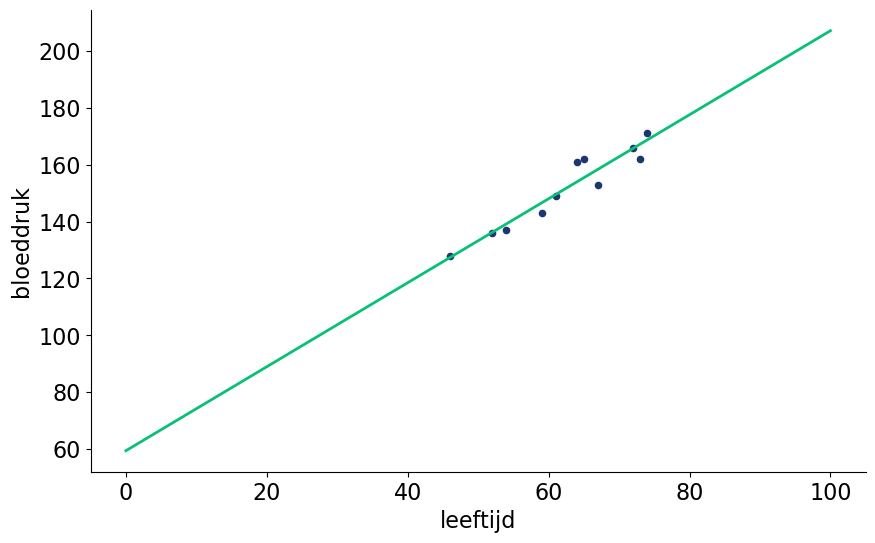

In [11]:
fig, ax = plt.subplots()
df.plot.scatter(x = 'leeftijd', y = 'bloeddruk', color = BLUE, ax = ax)
ax.plot([0, 100], [theta_0, theta_0 + theta_1 * 100], lw = 2, color = GREEN)
# fig.savefig(os.path.join(locs['bloeddruk_figs'], 'scatter_1d_with_reg.png'))

In [12]:
# Voorspelling maken voor iemand van 50 jaar
59.4 + 1.5 * 50

134.4

### Ditzelfde procedee in sklearn

In [13]:
from sklearn.linear_model import LinearRegression
model = LinearRegression() # Kan je vervangen door eenders welk predictief model
X = df.leeftijd.values.reshape(-1, 1)
y = df.bloeddruk.values.reshape(-1, 1)
model.fit(X, y) # Hier doen we de training voor optimale parameters te zoeken
test_predictions = model.predict(np.array([[50]]))
print(model.coef_) # \hat \theta_0
print(model.intercept_) # \hat \theta_1

[[1.47680018]]
[59.40347997]


### Model performantie evalueren

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
model.fit(X_train, y_train)
y_pred = np.round(model.predict(X_test)).astype(int)

In [16]:
print(f"MAE: {mean_absolute_error(y_pred, y_test)}")
print(f"MSE: {mean_squared_error(y_pred, y_test)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_pred, y_test))}")
print(f"MAPE: {100 * mean_absolute_percentage_error(y_pred, y_test):.2f}%")

MAE: 1.0
MSE: 3.0
RMSE: 1.7320508075688772
MAPE: 0.60%


Text(0, 0.5, 'Voorspelde bloeddruk')

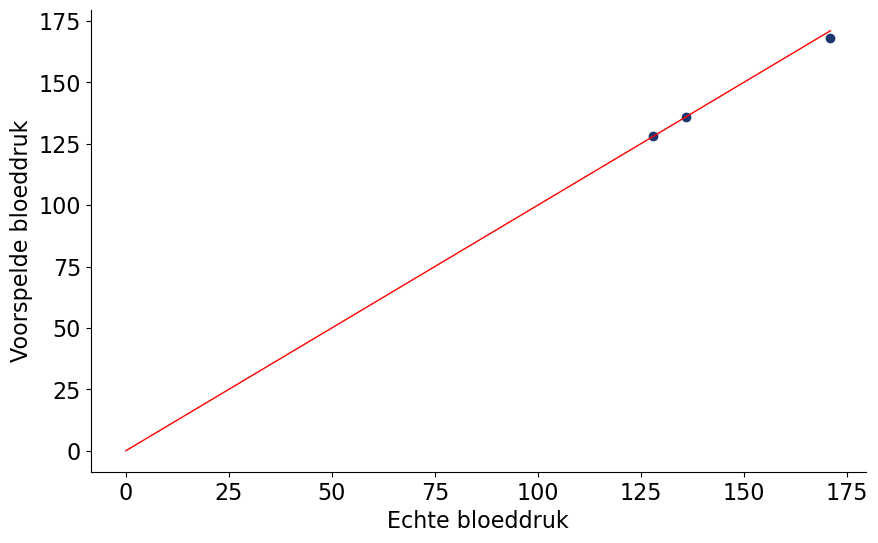

In [17]:
fig, ax = plt.subplots()
max_y = max(y_test.max(), y_pred.max())
ax.plot([0, max_y], [0, max_y], color = 'r', lw = 1)
ax.scatter(x = y_test, y = y_pred, color = BLUE)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel("Echte bloeddruk")
ax.set_ylabel("Voorspelde bloeddruk")
# fig.savefig(os.path.join(locs['bloeddruk_figs'], 'pred_vs_actual.png'))

## Wat met meerdere features

,leeftijd,gewicht,bloeddruk
leeftijd,1.000000,0.936927,0.955477
gewicht,0.936927,1.000000,0.947494
bloeddruk,0.955477,0.947494,1.000000


,leeftijd,gewicht,bloeddruk
leeftijd,1.000000,0.877833,0.912937
gewicht,0.877833,1.000000,0.897744
bloeddruk,0.912937,0.897744,1.000000


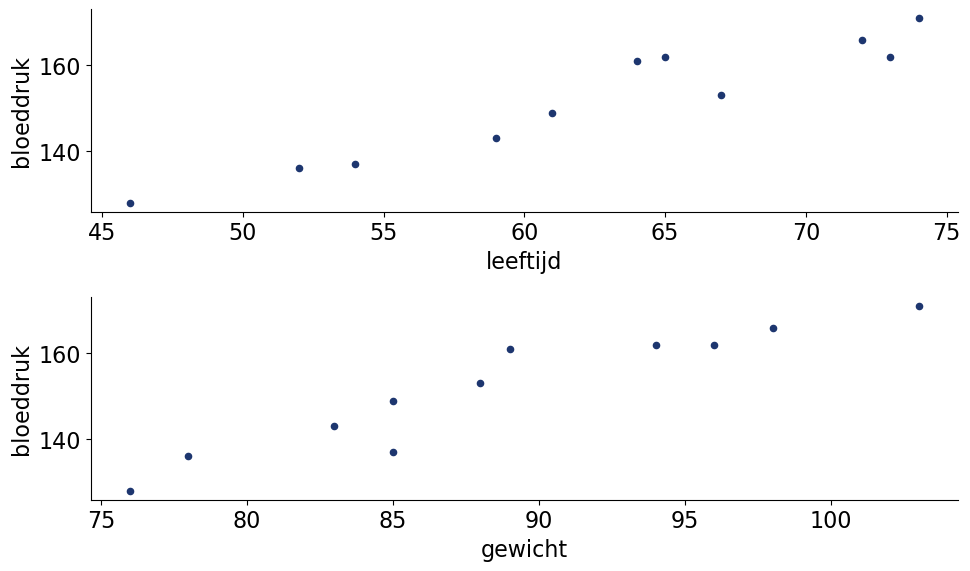

In [18]:
display(df.corr())
display(df.corr()**2)

fig, axs = plt.subplots(2, 1)
df.plot.scatter(x = 'leeftijd', y = 'bloeddruk', color = BLUE, ax = axs[0])

df.plot.scatter(x = 'gewicht', y = 'bloeddruk', color = BLUE, ax = axs[1])

for ax in axs:
    ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()

# fig.savefig(os.path.join(locs['bloeddruk_figs'], 'scatter_2d.png'))

### Model maken en trainen

In [19]:
X = df[['leeftijd', 'gewicht']].values
y = df[['bloeddruk']].values
model = LinearRegression()
model.fit(X, y) # Closed solution: \hat \theta = (X^TX)^{-1}X^TY

LinearRegression()

In [20]:
y

array([[136],
       [143],
       [153],
       [162],
       [161],
       [171],
       [137],
       [149],
       [162],
       [128],
       [166]], dtype=int64)